# Fixing a miscalibrated model with the KLCE penalty

When `KLCE_test` says a model is not locally calibrated, `recalibrated_model`
can fix it. It trains a small correction on top of the base probabilities by
minimizing a combination of:

- a **KLCE penalty** (`beta`) that drives the model toward local calibration, and
- a **distillation** term (`alpha`) that keeps it close to the original model, so
  ranking / discrimination is preserved.

We measure success three ways: the KLCE p-value should stop rejecting, the ECE
should drop, and the AUC should not degrade.

In [1]:
import numpy as np
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

import kernel_calibration as kc
from kernel_calibration import plots as kcplots

## A miscalibrated model

In [2]:
X, y, f = kc.make_calibration_data(n=2000, miscalibration=0.25, seed=1)
pw, xw = kc.select_bandwidths(X, f)

stat_before, p_before = kc.KLCE_test(X, y, f, pw, 300, key=0, x_kernel_width=xw)
print("BEFORE recalibration")
print(f"  KLCE p-value = {float(p_before):.4f}")
print(f"  ECE          = {kc.expected_calibration_error(y, f):.4f}")
print(f"  Brier        = {kc.brier_score(y, f):.4f}")
print(f"  AUC          = {roc_auc_score(y, f):.4f}")

BEFORE recalibration


  KLCE p-value = 0.0033
  ECE          = 0.0984
  Brier        = 0.1711
  AUC          = 0.8458


## Train the recalibrator

We weight the KLCE penalty heavily (`beta=1.0`) with a light distillation term
(`alpha=0.02`). The kernel widths reuse the median-heuristic values.

In [3]:
model = kc.recalibrated_model(
    sigma_k=pw, sigma_l=xw,
    alpha=0.02, beta=1.0,
    num_steps=1500, learning_rate=0.03,
    seed=0,
)
model.fit(f, X, y)
f_hat = np.asarray(model.predict_proba(f, X))

## Did it work?

In [4]:
stat_after, p_after = kc.KLCE_test(X, y, f_hat, pw, 300, key=0, x_kernel_width=xw)
print("AFTER recalibration")
print(f"  KLCE p-value = {float(p_after):.4f}")
print(f"  ECE          = {kc.expected_calibration_error(y, f_hat):.4f}")
print(f"  Brier        = {kc.brier_score(y, f_hat):.4f}")
print(f"  AUC          = {roc_auc_score(y, f_hat):.4f}")

AFTER recalibration


  KLCE p-value = 0.1395
  ECE          = 0.0311
  Brier        = 0.1559
  AUC          = 0.8530


The p-value climbs above 0.05 (the test no longer rejects local calibration),
ECE and Brier drop, and AUC is preserved — the model is recalibrated **without**
sacrificing its ability to rank.

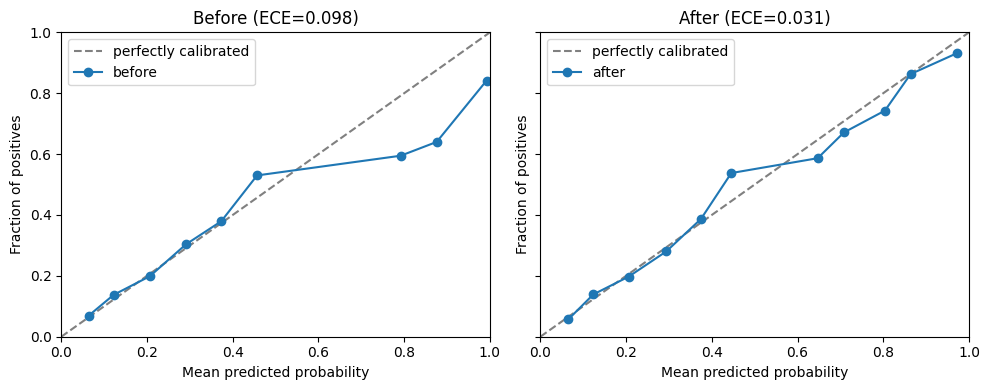

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
kcplots.reliability_diagram(y, f, n_bins=12, ax=ax1, label="before")
ax1.set_title(f"Before (ECE={kc.expected_calibration_error(y, f):.3f})")
kcplots.reliability_diagram(y, f_hat, n_bins=12, ax=ax2, label="after")
ax2.set_title(f"After (ECE={kc.expected_calibration_error(y, f_hat):.3f})")
fig.tight_layout()
plt.show()

## Training curve

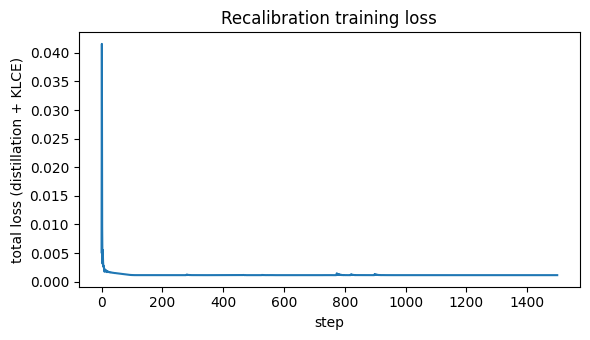

In [6]:
plt.figure(figsize=(6, 3.5))
plt.plot(model.loss_history)
plt.xlabel("step")
plt.ylabel("total loss (distillation + KLCE)")
plt.title("Recalibration training loss")
plt.tight_layout()
plt.show()